## Imports

In [63]:
import pandas as pd
import numpy as np

from statsmodels.tsa.statespace.varmax import VARMAX

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

## Load Data

In [64]:
import pandas as pd

df = pd.read_csv("../data/processed/weather_clean.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")
df = df.set_index("timestamp")

print(df.shape)
df.head()

(9392, 13)


,temperature_c,station_pressure_hpa,sea_level_pressure_hpa,pressure_change_hpa,humidity_pct,wind_speed_ms,visibility,dew_point_c,precipitation_mm,precipitation_period_h,cloud_cover_encoded,wind_dir_sin,wind_dir_cos
timestamp,,,,,,,,,,,,,
2019-01-01 00:00:00,6.2,762.6,770.5,0.0,86.0,1.0,10.0,4.0,0.0,0.0,0.0,0.707107,-0.707107
2019-01-01 03:00:00,7.6,763.0,770.8,0.4,85.0,2.0,10.0,5.2,0.0,0.0,0.0,0.707107,-0.707107
2019-01-01 06:00:00,4.8,763.1,771.0,0.1,88.0,1.0,8.0,3.0,0.0,0.0,0.0,0.707107,-0.707107
2019-01-01 09:00:00,8.9,765.0,772.8,1.9,88.0,1.0,10.0,7.0,0.0,0.0,0.0,0.382683,-0.923880
2019-01-01 12:00:00,17.2,764.7,772.3,-0.3,51.0,1.0,10.0,7.0,0.0,0.0,0.0,-0.923880,-0.382683


## Targets & data split

In [65]:
targets = [
    "temperature_c",
    "humidity_pct",
    "sea_level_pressure_hpa",
    "wind_speed_ms",
    "precipitation_mm"
]

train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

train_endog = train[targets]
test_endog = test[targets]

print(train_endog.shape)
print(test_endog.shape)

(7513, 5)
(1879, 5)


## select lag order

In [66]:
from statsmodels.tsa.api import VAR

model = VAR(train_endog)

lag_order_results = model.select_order(maxlags=16)

print(lag_order_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        14.03       14.03   1.238e+06       14.03
1        8.109       8.137       3326.       8.119
2        7.575       7.626       1949.       7.593
3        7.265       7.339       1429.       7.290
4        6.950       7.047       1043.       6.983
5        6.572       6.692       714.6       6.613
6        6.407       6.550       606.1       6.456
7        6.131       6.297       460.0       6.188
8        6.009       6.198       406.9       6.074
9        5.838       6.051       343.2       5.911
10       5.799      6.034*       329.9       5.880
11       5.782       6.041       324.6       5.871
12       5.781       6.063       324.1       5.878
13       5.777       6.082       322.9       5.882
14       5.774       6.102       321.9       5.887
15       5.747       6.098       313.3       5.868
16      5.714*       6.088     

## Fit VAR

In [67]:
from statsmodels.tsa.api import VAR

model_var = VAR(train_endog)

var_results = model_var.fit(10)

In [68]:
print(var_results.k_ar)

10


## generate forecast

In [69]:
forecast_steps = 80

var_forecast = var_results.forecast(
    y=train_endog.values[-10:],
    steps=forecast_steps
)

In [70]:
print(var_forecast.shape)

(80, 5)


## forecast to dataframe

In [71]:
var_forecast = pd.DataFrame(
    var_forecast,
    index=test_endog.index[:80],
    columns=test_endog.columns
)

In [72]:
print(var_forecast.shape)
var_forecast.head()

(80, 5)


,temperature_c,humidity_pct,sea_level_pressure_hpa,wind_speed_ms,precipitation_mm
timestamp,,,,,
2021-08-05 21:00:00,20.834932,74.035074,760.114767,1.006584,-1.450550
2021-08-06 00:00:00,16.171535,99.021070,760.154262,-2.070580,56.467063
2021-08-06 03:00:00,11.388022,116.804324,759.845526,-1.874093,-4.116645
2021-08-06 06:00:00,10.584145,117.443818,759.484614,-1.099072,17.401979
2021-08-06 09:00:00,18.806799,80.277430,759.384581,1.368457,0.032203


In [73]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_model(y_true, y_pred):

    metrics = []

    for col in y_true.columns:

        mae = mean_absolute_error(
            y_true[col],
            y_pred[col]
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_true[col],
                y_pred[col]
            )
        )

        r2 = r2_score(
            y_true[col],
            y_pred[col]
        )

        metrics.append([
            col,
            mae,
            rmse,
            r2
        ])

    return pd.DataFrame(
        metrics,
        columns=[
            "Variable",
            "MAE",
            "RMSE",
            "R2"
        ]
    )

In [74]:
var_metrics = evaluate_model(
    test_endog.iloc[:80],
    var_forecast
)

print(var_metrics)

                 Variable        MAE       RMSE        R2
0           temperature_c   6.065818   6.901992 -3.536958
1            humidity_pct  10.424742  13.025637 -0.153053
2  sea_level_pressure_hpa   1.496093   1.745949 -2.564498
3           wind_speed_ms   1.349940   1.681471 -0.371770
4        precipitation_mm   2.875444   8.858018  0.000000


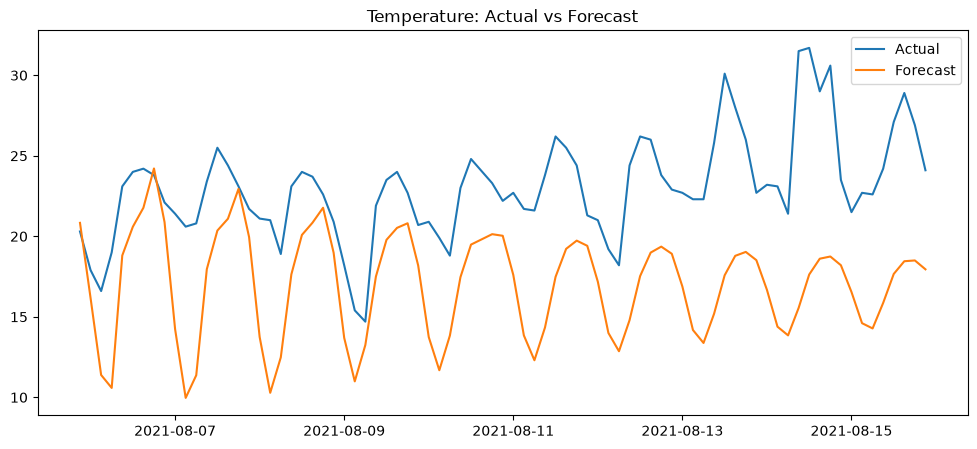

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    test_endog.index[:80],
    test_endog["temperature_c"].iloc[:80],
    label="Actual"
)

plt.plot(
    test_endog.index[:80],
    var_forecast["temperature_c"],
    label="Forecast"
)

plt.legend()
plt.title("Temperature: Actual vs Forecast")
plt.show()

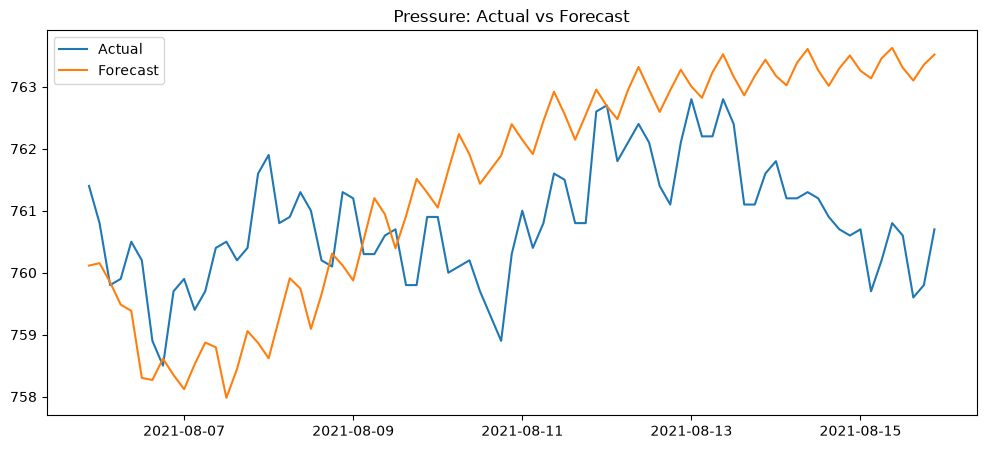

In [76]:
plt.figure(figsize=(12,5))

plt.plot(
    test_endog.index[:80],
    test_endog["sea_level_pressure_hpa"].iloc[:80],
    label="Actual"
)

plt.plot(
    test_endog.index[:80],
    var_forecast["sea_level_pressure_hpa"],
    label="Forecast"
)

plt.legend()
plt.title("Pressure: Actual vs Forecast")
plt.show()

In [77]:
horizons = [8, 16, 40, 80]

results = []

for horizon in horizons:

    forecast = var_results.forecast(
        y=train_endog.values[-var_results.k_ar:],
        steps=horizon
    )

    forecast = pd.DataFrame(
        forecast,
        index=test_endog.index[:horizon],
        columns=test_endog.columns
    )

    metrics = evaluate_model(
        test_endog.iloc[:horizon],
        forecast
    )

    metrics["Horizon"] = horizon

    results.append(metrics)

comparison = pd.concat(results)

comparison

,Variable,MAE,RMSE,R2,Horizon
0,temperature_c,3.304320,4.144068,-1.118567,8
1,humidity_pct,12.039737,14.697169,-0.681805,8
2,sea_level_pressure_hpa,0.768577,0.968088,-0.171492,8
3,wind_speed_ms,1.566462,1.820218,-0.204798,8
4,precipitation_mm,15.695857,25.691452,0.000000,8
0,temperature_c,4.308412,5.357892,-3.789615,16
1,humidity_pct,13.238235,16.260302,-1.527945,16
2,sea_level_pressure_hpa,1.137997,1.317135,-2.672844,16
3,wind_speed_ms,1.640203,1.946329,-0.480578,16
4,precipitation_mm,11.034717,19.560739,0.000000,16


## Traing 5 separate sarimax

### Temperature

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

temp_train = train["temperature_c"]
temp_test = test["temperature_c"]

model = SARIMAX(
    temp_train,
    order=(2,1,2),
    seasonal_order=(1,1,1,8),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

In [ ]:
forecast = results.forecast(steps=80)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

actual = temp_test.iloc[:80]

print("MAE :", mean_absolute_error(actual, forecast))
print("RMSE:", np.sqrt(mean_squared_error(actual, forecast)))
print("R2  :", r2_score(actual, forecast))

MAE : 1.9500791984016903
RMSE: 2.8310177801435774
R2  : 0.23668980140343865


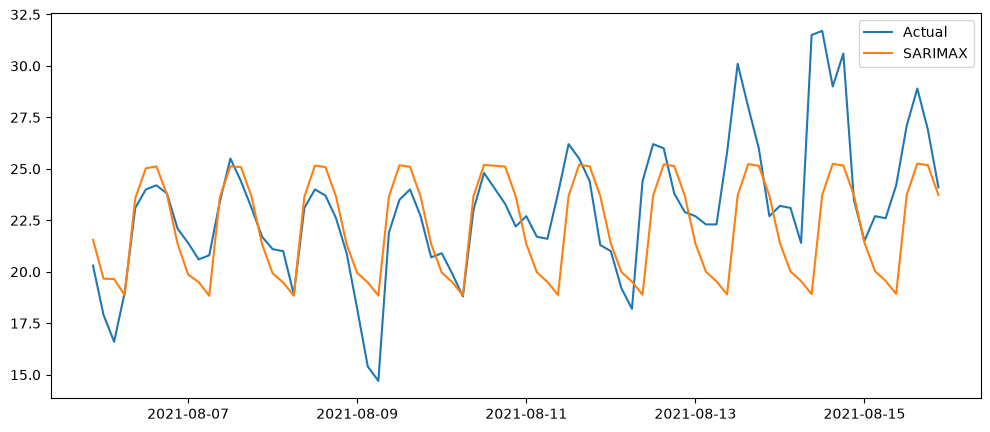

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(actual.index, actual, label="Actual")
plt.plot(actual.index, forecast, label="SARIMAX")

plt.legend()
plt.show()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

targets = [
    "temperature_c",
    "humidity_pct",
    "sea_level_pressure_hpa",
    "wind_speed_ms",
    "precipitation_mm"
]

forecast_horizon = 80

all_forecasts = {}
all_residuals = {}
all_models = []

for target in targets:

    print(f"\nTraining SARIMAX for {target}...")

    train_series = train[target]
    test_series = test[target]

    model = SARIMAX(
        train_series,
        order=(2,1,2),
        seasonal_order=(1,1,1,8),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    results = model.fit(disp=False)

    forecast = results.forecast(steps=forecast_horizon)

    residuals = results.resid

    all_forecasts[target] = forecast
    all_residuals[target] = residuals

    mae = mean_absolute_error(
        test_series.iloc[:forecast_horizon],
        forecast
    )

    rmse = np.sqrt(
        mean_squared_error(
            test_series.iloc[:forecast_horizon],
            forecast
        )
    )

    r2 = r2_score(
        test_series.iloc[:forecast_horizon],
        forecast
    )

    all_models.append([
        target,
        mae,
        rmse,
        r2
    ])

metrics_df = pd.DataFrame(
    all_models,
    columns=[
        "Variable",
        "MAE",
        "RMSE",
        "R2"
    ]
)

metrics_df


Training SARIMAX for temperature_c...

Training SARIMAX for humidity_pct...

Training SARIMAX for sea_level_pressure_hpa...

Training SARIMAX for wind_speed_ms...

Training SARIMAX for precipitation_mm...


,Variable,MAE,RMSE,R2
0,temperature_c,1.950079,2.831018,0.236690
1,humidity_pct,6.841578,9.445534,0.393677
2,sea_level_pressure_hpa,3.681481,4.285029,-20.470545
3,wind_speed_ms,1.060506,1.242782,0.250638
4,precipitation_mm,12.624149,13.580085,0.000000


## Persistence

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import pandas as pd
import numpy as np

forecast_horizon = 80

persistence_results = []

for target in targets:

    last_value = train[target].iloc[-1]

    forecast = np.repeat(
        last_value,
        forecast_horizon
    )

    actual = test[target].iloc[:forecast_horizon]

    persistence_results.append([
        target,
        mean_absolute_error(actual, forecast),
        np.sqrt(mean_squared_error(actual, forecast)),
        r2_score(actual, forecast)
    ])

persistence_df = pd.DataFrame(
    persistence_results,
    columns=[
        "Variable",
        "MAE",
        "RMSE",
        "R2"
    ]
)

persistence_df

,Variable,MAE,RMSE,R2
0,temperature_c,2.6500,3.446810,-0.131490
1,humidity_pct,10.8125,12.608033,-0.080304
2,sea_level_pressure_hpa,0.7975,1.014643,-0.203821
3,wind_speed_ms,1.8375,2.331845,-1.638162
4,precipitation_mm,0.0000,0.000000,1.000000


## Exponential smoothing

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ets_results = []

ets_forecasts = {}
ets_residuals = {}

for target in targets:

    train_series = train[target]
    test_series = test[target]

    model = ExponentialSmoothing(
        train_series,
        trend="add",
        seasonal="add",
        seasonal_periods=8
    )

    fitted = model.fit()

    forecast = fitted.forecast(80)

    ets_forecasts[target] = forecast
    ets_residuals[target] = fitted.resid

    ets_results.append([
        target,
        mean_absolute_error(
            test_series.iloc[:80],
            forecast
        ),
        np.sqrt(
            mean_squared_error(
                test_series.iloc[:80],
                forecast
            )
        ),
        r2_score(
            test_series.iloc[:80],
            forecast
        )
    ])

ets_df = pd.DataFrame(
    ets_results,
    columns=[
        "Variable",
        "MAE",
        "RMSE",
        "R2"
    ]
)

ets_df

,Variable,MAE,RMSE,R2
0,temperature_c,1.928906,2.754225,0.277538
1,humidity_pct,6.649388,9.329459,0.408487
2,sea_level_pressure_hpa,6.976251,8.227963,-78.162617
3,wind_speed_ms,1.139246,1.373185,0.085127
4,precipitation_mm,14.374186,15.718410,0.000000


In [ ]:
comparison = pd.concat([
    persistence_df.assign(Model="Persistence"),
    ets_df.assign(Model="ETS"),
    metrics_df.assign(Model="SARIMAX")
])

comparison = comparison[
    ["Model", "Variable", "MAE", "RMSE", "R2"]
]

comparison.sort_values(
    ["Variable", "R2"],
    ascending=[True, False]
)

,Model,Variable,MAE,RMSE,R2
1,ETS,humidity_pct,6.649388,9.329459,0.408487
1,SARIMAX,humidity_pct,6.841578,9.445534,0.393677
1,Persistence,humidity_pct,10.812500,12.608033,-0.080304
4,Persistence,precipitation_mm,0.000000,0.000000,1.000000
4,ETS,precipitation_mm,14.374186,15.718410,0.000000
4,SARIMAX,precipitation_mm,12.624149,13.580085,0.000000
2,Persistence,sea_level_pressure_hpa,0.797500,1.014643,-0.203821
2,SARIMAX,sea_level_pressure_hpa,3.681481,4.285029,-20.470545
2,ETS,sea_level_pressure_hpa,6.976251,8.227963,-78.162617
0,ETS,temperature_c,1.928906,2.754225,0.277538


In [ ]:
best_models = comparison.loc[
    comparison.groupby("Variable")["R2"].idxmax()
]

best_models

,Model,Variable,MAE,RMSE,R2
1,Persistence,humidity_pct,10.812500,12.608033,-0.080304
1,ETS,humidity_pct,6.649388,9.329459,0.408487
1,SARIMAX,humidity_pct,6.841578,9.445534,0.393677
4,Persistence,precipitation_mm,0.000000,0.000000,1.000000
4,ETS,precipitation_mm,14.374186,15.718410,0.000000
4,SARIMAX,precipitation_mm,12.624149,13.580085,0.000000
2,Persistence,sea_level_pressure_hpa,0.797500,1.014643,-0.203821
2,ETS,sea_level_pressure_hpa,6.976251,8.227963,-78.162617
2,SARIMAX,sea_level_pressure_hpa,3.681481,4.285029,-20.470545
0,Persistence,temperature_c,2.650000,3.446810,-0.131490


## Extractind the residuals

In [ ]:
best_residuals = pd.DataFrame({
    "temperature_c": ets_residuals["temperature_c"],
    "humidity_pct": ets_residuals["humidity_pct"],
    "sea_level_pressure_hpa": np.nan,  # persistence
    "wind_speed_ms": all_residuals["wind_speed_ms"],  # SARIMAX
    "precipitation_mm": np.nan          # persistence
})

In [ ]:
pressure_residuals = (
    test["sea_level_pressure_hpa"].iloc[:80]
    - train["sea_level_pressure_hpa"].iloc[-1]
)

precip_residuals = (
    test["precipitation_mm"].iloc[:80]
    - train["precipitation_mm"].iloc[-1]
)

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

for variable, residuals in {
    "temperature_c": ets_residuals["temperature_c"],
    "humidity_pct": ets_residuals["humidity_pct"],
    "wind_speed_ms": all_residuals["wind_speed_ms"],
    "sea_level_pressure_hpq" : pressure_residuals,
    "precipitation_mm" : ets_residuals["precipitation_mm"]
}.items():

    print(f"\n{variable}")

    lb = acorr_ljungbox(
        residuals.dropna(),
        lags=[24],
        return_df=True
    )

    print(lb)


temperature_c
        lb_stat  lb_pvalue
24  3451.040579        0.0

humidity_pct
        lb_stat  lb_pvalue
24  2214.401742        0.0

wind_speed_ms
       lb_stat     lb_pvalue
24  173.935057  1.047565e-24

sea_level_pressure_hpq
       lb_stat     lb_pvalue
24  215.826613  8.764158e-33

precipitation_mm
       lb_stat     lb_pvalue
24  478.627179  4.521251e-86
